## 라이브러리

In [58]:
!pip install catboost

In [59]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.metrics import classification_report, confusion_matrix

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost

from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier


# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

## 데이터 불러오기

→ train, test 둘다 불러와서 인코딩/ 스케일링 까지 한번에 함

In [60]:
df = pd.read_csv("all_train.csv") 
test = pd.read_csv('all_test.csv')


In [61]:
train = pd.read_csv("C,D구분 피처 추가 49개 선택.csv")

In [62]:
# E에서 사용할 파일
train_E= df[['ID', 'Segment', '카드이용한도금액', '정상청구원금_B0M', '입회경과개월수_신용',
       '이용금액_R3M_신용체크', '_1순위카드이용금액', '최대이용금액_일시불_R12M', '정상입금원금_B0M', '이용금액대',
       '월중평잔', '이용금액_일시불_B0M', '최대이용금액_할부_R12M', '이용금액_R3M_신용', '쇼핑_도소매_이용금액',
       '이용금액_오프라인_R6M', '이용금액_할부_R12M', '잔액_신판ca최대한도소진율_r6m', '최종이용일자_CA',
       '연체입금원금_B0M', '이용금액_CA_R12M', '최종이용일자_할부', 'CL이자율_할인전', '_2순위쇼핑업종_이용금액',
       '_1순위업종_이용금액', '이용금액_할부_무이자_R3M', '이용금액_할부_무이자_B0M', 'CA이자율_할인전',
       '잔액_할부_B0M', '_2순위업종_이용금액', '최종이용일자_체크', '인입횟수_ARS_R6M', '캠페인접촉건수_R12M',
       '이용메뉴건수_ARS_R6M', '방문일수_PC_R6M', '방문횟수_앱_R6M', '방문횟수_PC_R6M',
       '이용후경과월_CA', '이용후경과월_할부', '인입후경과월_IB_R6M', '할부금액_유이자_3M_R12M',
       'RP후경과월_교통', 'RV약정청구율', '상향가능한도금액', '증감율_이용건수_할부_전월', '컨택건수_카드론_TM_R6M',
       '컨택건수_CA_LMS_R6M', '연속유실적개월수_기본_24M_카드', '이용카드수_신용체크', '이용후경과월_신용', '이용후경과월_일시불',
         '연속무실적개월수_기본_24M_카드', 'RP후경과월',
    '이용후경과월_할부_유이자', '이용후경과월_체크']]

In [63]:
test1 = test[['ID', '카드이용한도금액', '정상청구원금_B0M', '입회경과개월수_신용',
       '이용금액_R3M_신용체크', '_1순위카드이용금액', '최대이용금액_일시불_R12M', '정상입금원금_B0M', '이용금액대',
       '월중평잔', '이용금액_일시불_B0M', '최대이용금액_할부_R12M', '이용금액_R3M_신용', '쇼핑_도소매_이용금액',
       '이용금액_오프라인_R6M', '이용금액_할부_R12M', '잔액_신판ca최대한도소진율_r6m', '최종이용일자_CA',
       '연체입금원금_B0M', '이용금액_CA_R12M', '최종이용일자_할부',"" 'CL이자율_할인전', '_2순위쇼핑업종_이용금액',
       '_1순위업종_이용금액', '이용금액_할부_무이자_R3M', '이용금액_할부_무이자_B0M', 'CA이자율_할인전',
       '잔액_할부_B0M', '_2순위업종_이용금액', '최종이용일자_체크', '인입횟수_ARS_R6M', '캠페인접촉건수_R12M',
       '이용메뉴건수_ARS_R6M', '방문일수_PC_R6M', '방문횟수_앱_R6M', '방문횟수_PC_R6M',
       '이용후경과월_CA', '이용후경과월_할부', '인입후경과월_IB_R6M', '할부금액_유이자_3M_R12M',
       'RP후경과월_교통', 'RV약정청구율', '상향가능한도금액', '증감율_이용건수_할부_전월', '컨택건수_카드론_TM_R6M',
       '컨택건수_CA_LMS_R6M']]

#### 일반 파일 전처리

In [64]:
# test1에도 'ID'가 들어있으므로 나중에 제거
cat_cols = test1.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('ID')

In [65]:
encoder_dict = {}

In [66]:
all_data = pd.concat([train[cat_cols], test1[cat_cols]], axis=0)

In [67]:
for col in cat_cols:
    
    le = LabelEncoder()
    le.fit(all_data[col].astype(str))   # 둘 다 포함해서 fit
    encoder_dict[col] = le

In [68]:
# train 인코딩
for col in cat_cols:
    train[col] = encoder_dict[col].transform(train[col].astype(str)).astype(float)

# test1 인코딩
for col in cat_cols:
    test1[col] = encoder_dict[col].transform(test1[col].astype(str)).astype(float)

In [69]:
# train데이터 카피
df2 = train.copy()

In [70]:
# Segment 인코딩 사전
le_seg = LabelEncoder()
df2['Segment'] = le_seg.fit_transform(df2['Segment'])
seg_map = {cls: idx for idx, cls in enumerate(le_seg.classes_)}
print("Segment 인코딩 매핑 →", seg_map)

Segment 인코딩 매핑 → {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}


#### train_E 전처리

In [71]:
new_features = train_E.columns.difference(df2.columns)
print("🆕 새로 추가된 컬럼들:", new_features.tolist())

🆕 새로 추가된 컬럼들: ['RP후경과월', '연속무실적개월수_기본_24M_카드', '연속유실적개월수_기본_24M_카드', '이용카드수_신용체크', '이용후경과월_신용', '이용후경과월_일시불', '이용후경과월_체크', '이용후경과월_할부_유이자']


In [111]:
df_E = train_E.copy()

In [112]:
cat_cols = df_E.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('ID')
cat_cols.remove('Segment')

In [113]:
# Segment 인코딩 사전
le_seg = LabelEncoder()
df_E['Segment'] = le_seg.fit_transform(df_E['Segment'])
seg_map = {cls: idx for idx, cls in enumerate(le_seg.classes_)}
print("Segment 인코딩 매핑 →", seg_map)

Segment 인코딩 매핑 → {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}


In [114]:
from sklearn.preprocessing import LabelEncoder

# 각 범주형 컬럼별 라벨 인코딩
for col in cat_cols:
    if df_E[col].dtype == 'object':
        le = LabelEncoder()
        df_E[col] = le.fit_transform(df_E[col].astype(str))


In [115]:
X_train_E = df_E.drop(columns=['ID','Segment'])   # 또는 타깃 컬럼 이름에 따라 다름
y_train_E = df_E['Segment']

In [116]:
from sklearn.preprocessing import StandardScaler

# 수치형 컬럼만 추출
num_cols = X_train_E.select_dtypes(include=['int64', 'float64']).columns

# 스케일링
scaler = StandardScaler()
X_train_E[num_cols] = scaler.fit_transform(X_train_E[num_cols])


In [117]:
# 🎯 stratify를 y로 맞추면 클래스 비율(E:비E)을 유지한 채 분할됩니다
X_tr_E, X_val_E, y_tr_E, y_val_E = train_test_split(
    X_train_E, y_train_E,
    test_size=0.2,
    stratify=y_train_E,
    random_state=42
)

print("✅ 분할 완료:")
print(f" - 학습용: {X_tr_E.shape}, {y_tr_E.shape}")
print(f" - 검증용: {X_val_E.shape}, {y_val_E.shape}")


✅ 분할 완료:
 - 학습용: (1920000, 53), (1920000,)
 - 검증용: (480000, 53), (480000,)


#### train_E 전처리 끝

In [118]:
df3 = df2.copy()

In [119]:
# 입력과 결과로 나눈다
X = df3.drop(['ID','Segment'], axis = 1)
y = df3['Segment']

In [120]:
# 숫자형 컬럼 표준화 (이미 fit된 scaler 사용)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

X[num_cols] = scaler.fit_transform(X[num_cols])
test1[num_cols] = scaler.transform(test1[num_cols])


In [121]:
train_X = X
train_y = y

In [122]:
# 1️⃣ 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    train_X, train_y, test_size=0.2, stratify=y, random_state=42)

### 전처리 완료 !

---------------

## 예측 모델

### Gate 1) E와 E가 아닌 것으로 분류

In [123]:
# E 코드 값이 숫자형일 경우
E_code = seg_map['E']

# 🎯 이진 타깃 생성
y_tr_E_bin = (y_tr_E == E_code).astype(int)
y_val_E_bin = (y_val_E == E_code).astype(int)



 LightGBM 모델 학습 (E vs ¬E)

In [124]:
from lightgbm import LGBMClassifier

# ✅ LGBM 모델 정의
clf_e = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=9,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42
)

# ✅ 모델 학습
clf_e.fit(
    X_tr_E, y_tr_E_bin,
)


[LightGBM] [Info] Number of positive: 1537641, number of negative: 382359
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7916
[LightGBM] [Info] Number of data points in the train set: 1920000, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.03, max_depth=9, n_estimators=1000,
               num_leaves=64, random_state=42, subsample=0.8)

### 아래 코드에서 부터 문제 발생 ☠️☠️☠️

- E가 아닌데 E로 예측하는 애들이 너무 많다
- 최적의 임계값을 찾는 코드 아래에 추가함 --> 근데 recall 이랑 precision trade - off 됨

              precision    recall  f1-score   support

          ¬E       0.66      0.90      0.76     95589
           E       0.97      0.88      0.93    384411

    accuracy                           0.89    480000
   macro avg       0.82      0.89      0.84    480000
weighted avg       0.91      0.89      0.89    480000



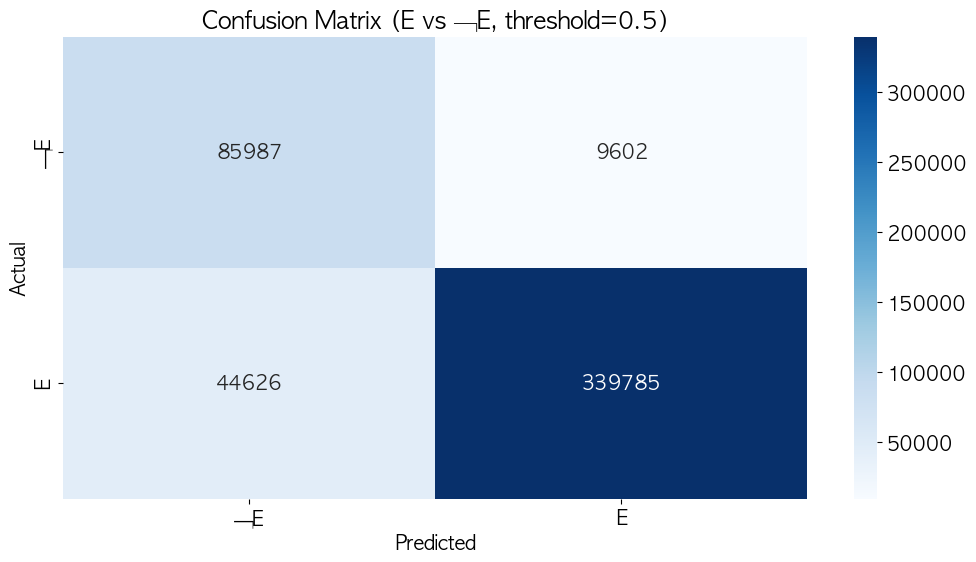

In [148]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 예측 확률
y_proba_bin = clf_e.predict_proba(X_val_E)[:, 1]

# ✅ 커트라인 적용
threshold = 0.5  # 🎯 낮춰보기 (0.4~0.45)
y_pred_bin = (y_proba_bin >= threshold).astype(int)

# ✅ 리포트 출력
print(classification_report(
    y_val_E_bin, y_pred_bin,
    labels=[0, 1],
    target_names=['¬E', 'E']
))

# ✅ Confusion Matrix 시각화
cm = confusion_matrix(y_val_E_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['¬E', 'E'], yticklabels=['¬E', 'E'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (E vs ¬E, threshold={threshold})")
plt.show()


#### 그래프를 그려보자

<강사님 피드백>


- 원래 E인데 E라고 예측한 애들의 E일 확률 
- 원래 E인데 E라고 예측되지 않을 애들의 E일 확률 
- 원래 E가 아닌데 E라고 예측하지 않을 확률
- 원래 E가 아닌데 E라고 예측할 확률 

* 확률 산점도 그려보기 *

- 잘 맞춘 애들이 0.5에서 멀어져있다.
- 잘 못맞춘 애들이 0.5에 몰려져있다. 그러면 임계 수치로 잘라도 된다는 이야기

확률의 임계치를 이용해 어느 수치 이상에 속하는 애들은 E로 
E냐 아니냐를 학습한 애가 던지는 결과에 대해 ...
"정확히 어떤 산점도를 그려야하는지 잘 모르겠음"

### 이정도면 E랑 E가 아닌 것으로 분류를 잘하는 피처가 없는거 아닐까 ?

ex) 월중평잔 으로 확인해봄

-----------------------

### Gate 2) D와 D가 아닌 것들로 분류
 E로 잘 맞춘 애들만 확정 → 나머지는 D vs ¬D로 넘기기

#### 1단계. "진짜 E" 중에서 정확히 맞춘 샘플만 필터링

In [126]:
import numpy as np

# 🎯 E 코드
E_code = seg_map['E']

# 1. E로 예측된 것 중 → 실제도 E인 경우
mask_confident_E = (y_pred_bin == 1) & (y_test == E_code)

# 2. E가 아니라고 확신되는 것 = 예측도 not E이고, 실제도 not E인 경우
mask_confident_not_E = (y_pred_bin == 0) & (y_test != E_code)



####  2단계. 나머지 샘플은 다음 모델 (D vs ¬D)로 넘기기

In [127]:
# 3. E 제외한 확실한 샘플로 필터링 (D 분류용으로 활용)
X_d_train = X_test[mask_confident_not_E]
y_d_train = y_test[mask_confident_not_E]

#### 3단계. 다음 분기용 타깃 생성 (D vs ¬D)

In [128]:
D_code = seg_map['D']
y_d_bin = (y_d_train == D_code).astype(int)

# 3피처셋 복사 
X_next = X_d_train.copy()
y_next = y_d_train.copy()

#### 4단계. D vs ¬D 분류 모델 학습

In [129]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_next, y_d_bin, test_size=0.2, stratify=y_d_bin, random_state=42
)

clf_d = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    class_weight='balanced',
    random_state=42
)

clf_d.fit(X_train_d, y_train_d)


[LightGBM] [Info] Number of positive: 48893, number of negative: 19896
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7824
[LightGBM] [Info] Number of data points in the train set: 68789, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.03, max_depth=7,
               n_estimators=800, random_state=42)

#### 5단계. 성능 확인

              precision    recall  f1-score   support

          ¬D       0.65      0.78      0.71      4974
           D       0.90      0.83      0.87     12224

    accuracy                           0.82     17198
   macro avg       0.78      0.80      0.79     17198
weighted avg       0.83      0.82      0.82     17198



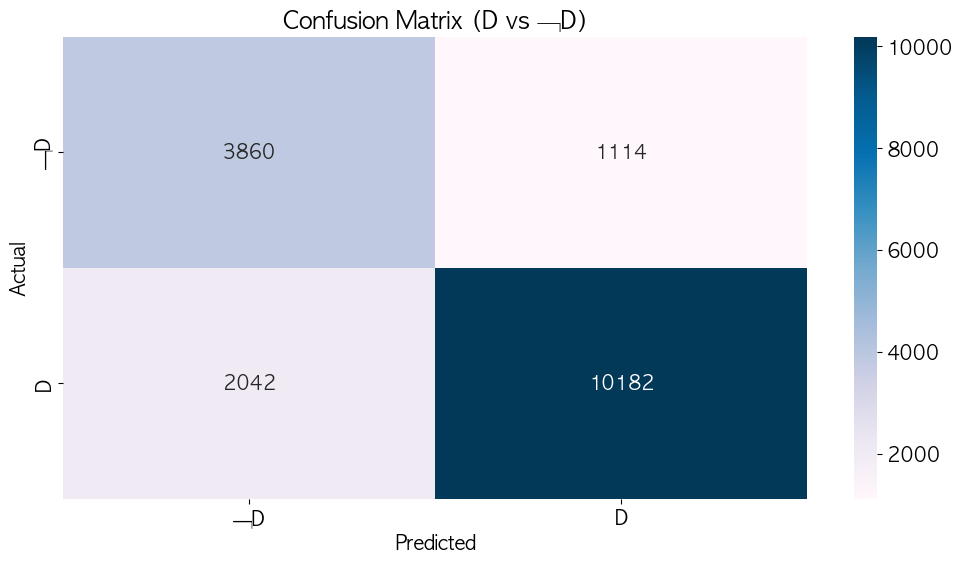

In [130]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_d = clf_d.predict(X_val_d)

print(classification_report(y_val_d, y_pred_d, target_names=['¬D', 'D']))

cm = confusion_matrix(y_val_d, y_pred_d)
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', xticklabels=['¬D', 'D'], yticklabels=['¬D', 'D'])
plt.title("Confusion Matrix (D vs ¬D)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


---------------------

### Gate 3) C와 C가 아닌 것으로 분류 (C vs A, B)

#### 1단계. C vs A vs B 학습용 데이터 만들기
D 분기 로직

In [131]:
# D 예측값 (1 = D, 0 = ¬D)
y_pred_d = clf_d.predict(X_next)

# D 클래스 코드
D_code = seg_map['D']

# 🎯 D 확정: 예측도 D이고, 실제도 D인 샘플
mask_confident_D = (y_pred_d == 1) & (y_next == D_code)

# 🎯 다음 분기 대상: 예측이 ¬D이고, 실제도 ¬D인 샘플
mask_confident_non_D = (y_pred_d == 0) & (y_next != D_code)

# ✅ 분기
X_D_confident = X_next[mask_confident_D]
y_D_confident = y_next[mask_confident_D]

X_cand = X_next[mask_confident_non_D]
y_cand = y_next[mask_confident_non_D]


In [132]:
print("C 개수:", (y_cand == seg_map['C']).sum())
print("B 개수:", (y_cand == seg_map['B']).sum())
print("A 개수:", (y_cand == seg_map['A']).sum())


C 개수: 20581
B 개수: 29
A 개수: 193


#### 2단계. C → 1, A/B → 0 로 이진 타깃 생성

In [133]:
# seg_map에서 코드 매핑 확인
C_code = seg_map['C']

# C면 1, A/B면 0
y_c_ab_bin = y_cand.apply(lambda x: 1 if x == C_code else 0)


#### 3단계. 학습/검증 세트 분리

In [134]:
X_train_cab, X_val_cab, y_train_cab, y_val_cab = train_test_split(
    X_cand, y_c_ab_bin,
    test_size=0.2,
    stratify=y_c_ab_bin,
    random_state=42
)


#### 4단계. LightGBM 학습 (GPU)


In [135]:
clf_c_ab = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    class_weight= "balanced",
    random_state=42
)

clf_c_ab.fit(X_train_cab, y_train_cab)


[LightGBM] [Info] Number of positive: 16464, number of negative: 178
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7827
[LightGBM] [Info] Number of data points in the train set: 16642, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBMClassifier(class_weight='balanced', learning_rate=0.03, max_depth=7,
               n_estimators=800, random_state=42)

####  5단계. 성능 평가

              precision    recall  f1-score   support

         A·B       0.58      0.32      0.41        44
           C       0.99      1.00      1.00      4117

    accuracy                           0.99      4161
   macro avg       0.79      0.66      0.70      4161
weighted avg       0.99      0.99      0.99      4161



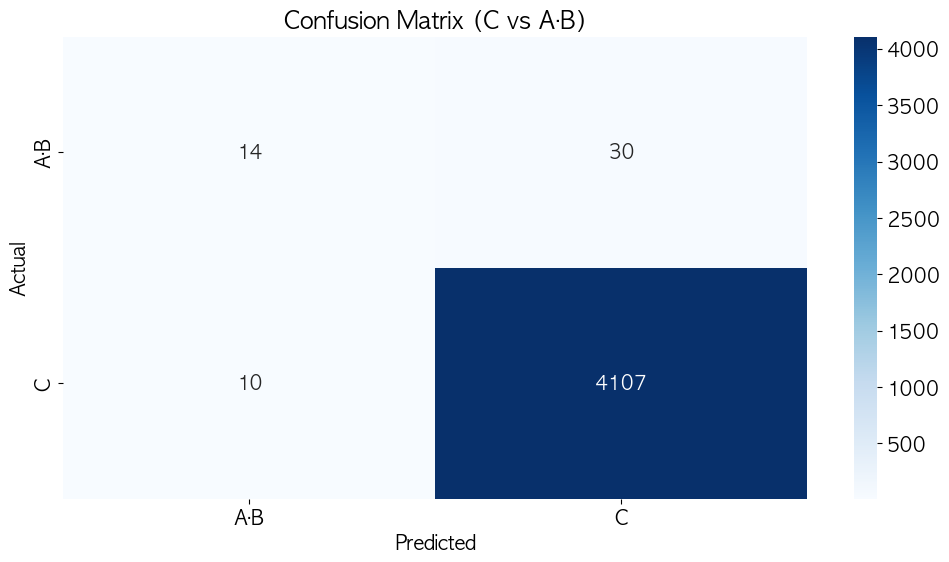

In [136]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 예측
y_pred_cab = clf_c_ab.predict(X_val_cab)

# 클래스 이름 (1 = C, 0 = A/B)
target_names = ['A·B', 'C']  # 순서 중요!

# 리포트 출력
print(classification_report(
    y_val_cab,
    y_pred_cab,
    labels=[0, 1],
    target_names=target_names
))

# 혼동행렬 시각화
cm = confusion_matrix(y_val_cab, y_pred_cab, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix (C vs A·B)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


-----------------

### Gate 4) A vs B 후보 검출

#### 1단계. A vs B 후보 샘플 추출

In [137]:
# 1️⃣ C 예측값: 1 = C, 0 = A·B
y_pred_c = clf_c_ab.predict(X_cand)

# 2️⃣ C 클래스 코드
C_code = seg_map['C']

# 3️⃣ 🎯 C 확정 샘플 (예측=1 & 실제=C)
mask_confident_C = (y_pred_c == 1) & (y_cand == C_code)

# 4️⃣ 🎯 A/B 후보 샘플 (예측=0 & 실제≠C)
mask_confident_non_C = (y_pred_c == 0) & (y_cand != C_code)

# ✅ 분기
X_C = X_cand[mask_confident_C]
y_C = y_cand[mask_confident_C]

X_ab = X_cand[mask_confident_non_C]
y_ab = y_cand[mask_confident_non_C]


#### A vs B 타깃 이진화

#### 2단계. 학습/검증 데이터 분리

In [138]:

X_train_ab, X_val_ab, y_train_ab, y_val_ab = train_test_split(
    X_ab, y_ab,
    test_size=0.2,
    stratify=y_ab,
    random_state=42
)


####  3단계. LightGBM 모델 학습

In [139]:

clf_ab = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    class_weight='balanced',  # 매우 불균형할 수 있음
    random_state=42
)

clf_ab.fit(X_train_ab, y_train_ab)


[LightGBM] [Info] Number of positive: 19, number of negative: 134
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000628 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1351
[LightGBM] [Info] Number of data points in the train set: 153, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBMClassifier(class_weight='balanced', learning_rate=0.03, max_depth=6,
               n_estimators=600, random_state=42)

#### 4단계. 성능 확인

A 코드: 0 / B 코드: 1
              precision    recall  f1-score   support

           A       0.97      1.00      0.99        34
           B       1.00      0.80      0.89         5

    accuracy                           0.97        39
   macro avg       0.99      0.90      0.94        39
weighted avg       0.98      0.97      0.97        39



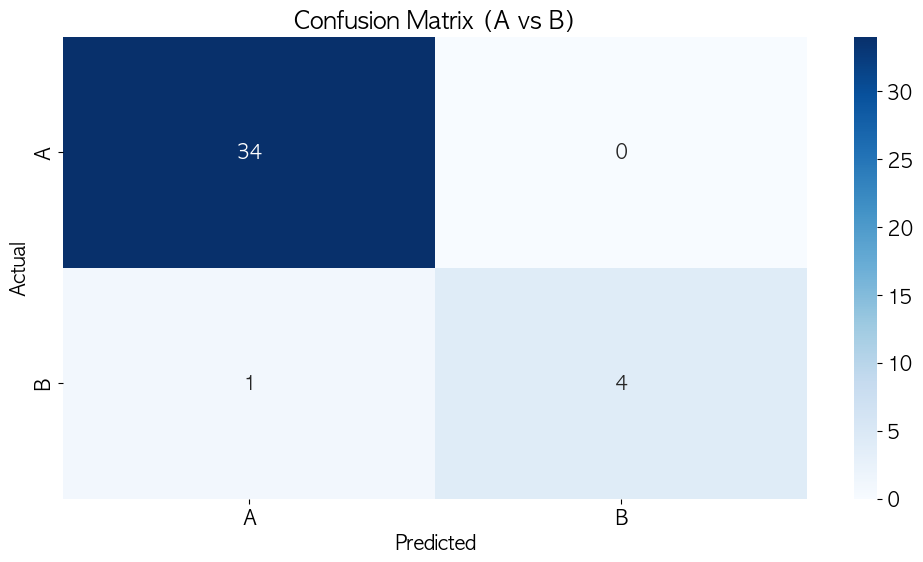

In [140]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_ab = clf_ab.predict(X_val_ab)

# 레이블 순서 확인
print("A 코드:", seg_map['A'], "/ B 코드:", seg_map['B'])

# 리포트
print(classification_report(
    y_val_ab,
    y_pred_ab,
    labels=[seg_map['A'], seg_map['B']],
    target_names=['A', 'B']
))

# 혼동행렬
cm = confusion_matrix(y_val_ab, y_pred_ab, labels=[seg_map['A'], seg_map['B']])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['A','B'], yticklabels=['A','B'])
plt.title("Confusion Matrix (A vs B)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


--------------------------

### 성능 평가) 혼동행렬

### 전체 성능 평가

#### 1. 단계별 분기 재현

In [141]:
import numpy as np

# 1️⃣ E vs ¬E 분기
# 얘만 피처가 47개라 고쳐야함
# ✅ E 분류기 예측용: 누락된 피처 채우고 순서 맞추기
X_test_e = X_test.copy()

missing_cols = set(X_train_E.columns) - set(X_test.columns)
for col in missing_cols:
    X_test_e[col] = 0  # 또는 평균, 중위값 등으로 대체 가능

X_test_e = X_test_e[X_train_E.columns]  # 컬럼 순서 맞추기

# ✅ 예측 수행
y_pred_bin = clf_e.predict(X_test_e)

mask_true_E = (y_test == seg_map['E'])        # 실제 E
mask_pred_E = (y_pred_bin == 1)               # 예측 E
mask_confident_E = mask_true_E & mask_pred_E  # 확신하는 E

X_E = X_test[mask_confident_E]
y_E_true = y_test[mask_confident_E]
y_E_pred = np.full_like(y_E_true, seg_map['E'])

# 나머지 → D 분기 대상으로 넘김
mask_next = ~mask_confident_E
X_next = X_test[mask_next]
y_next = y_test[mask_next]

# 2️⃣ D vs ¬D 분기
y_pred_d = clf_d.predict(X_next)
mask_true_D = (y_next == seg_map['D'])
mask_pred_D = (y_pred_d == 1)
mask_confident_D = mask_true_D & mask_pred_D

X_D = X_next[mask_confident_D]
y_D_true = y_next[mask_confident_D]
y_D_pred = np.full_like(y_D_true, seg_map['D'])

# 나머지 → C 분기 대상으로 넘김
mask_next2 = ~mask_confident_D
X_cand = X_next[mask_next2]
y_cand = y_next[mask_next2]

# 3️⃣ C vs A·B 분기
y_pred_c = clf_c_ab.predict(X_cand)
mask_true_C = (y_cand == seg_map['C'])
mask_pred_C = (y_pred_c == 1)
mask_confident_C = mask_true_C & mask_pred_C

X_C = X_cand[mask_confident_C]
y_C_true = y_cand[mask_confident_C]
y_C_pred = np.full_like(y_C_true, seg_map['C'])

# 나머지 → A vs B 최종 분류
mask_ab = ~mask_confident_C
X_ab = X_cand[mask_ab]
y_ab = y_cand[mask_ab]

y_pred_ab = clf_ab.predict(X_ab)
y_AB_true = y_ab
y_AB_pred = y_pred_ab


#### 2. 혼동행렬 출력

In [142]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report

# 🎯 전체 예측 결과
y_true_total = np.concatenate([y_E_true, y_D_true, y_C_true, y_AB_true])
y_pred_total = np.concatenate([y_E_pred, y_D_pred, y_C_pred, y_AB_pred])

# 🔁 숫자 → 문자 클래스 변환
inv_seg_map = {v: k for k, v in seg_map.items()}
y_true_named = pd.Series(y_true_total).map(inv_seg_map)
y_pred_named = pd.Series(y_pred_total).map(inv_seg_map)

# ✅ 혼동행렬 출력 (합계 제외)
conf_matrix_df = pd.crosstab(
    y_true_named, y_pred_named,
    rownames=['Actual'], colnames=['Predicted'],
    margins=False  # ← 합계 제거!
)

# 📊 출력
print("\n📊 혼동행렬 (Confusion Matrix - Text)")
display(conf_matrix_df)

# 🎯 F1 점수 출력
print(f"\n🎯 Micro-F1 : {f1_score(y_true_total, y_pred_total, average='micro'):.4f}")
print(f"\n🎯 Macro-F1 : {f1_score(y_true_total, y_pred_total, average='macro'):.4f}")



📊 혼동행렬 (Confusion Matrix - Text)


Predicted,A,B,C,D,E
Actual,,,,,
A,193,1,0,0,0
B,2,27,0,0,0
C,10,0,25508,0,0
D,3467,5831,0,60550,0
E,4574,18444,0,0,361393



🎯 Micro-F1 : 0.9326

🎯 Macro-F1 : 0.5891


threshold 조정
진짜 E만 E로 보고 있다
E

### 전체 데이터로 분기 및 예측

In [144]:
10/0

ZeroDivisionError: division by zero

------------------

## TEST 파일 예측

In [ ]:
# ✅ ID 분리
test_id = test1['ID']
X_test1 = test1.drop(columns=['ID'])

# ✅ 컬럼 순서 정의
features_e = clf_e.feature_name_
features_common = clf_d.feature_name_

# ✅ 예측 결과 저장용 시리즈
final_pred = pd.Series(index=X_test1.index, dtype=int)

# 1️⃣ E vs ¬E
X_input_e = X_test1.reindex(columns=features_e)
y_pred_e = clf_e.predict(X_input_e)
proba_e = clf_e.predict_proba(X_input_e)[:, 1]
mask_E = (y_pred_e == 1) & (proba_e >= 0.9)

final_pred.loc[mask_E] = seg_map['E']
X_next = X_test1.loc[~mask_E, features_common]  # 나머지 → 다음 분기

# 2️⃣ D vs ¬D
if not X_next.empty:
    y_pred_d = clf_d.predict(X_next)
    proba_d = clf_d.predict_proba(X_next)[:, 1]
    mask_D = (y_pred_d == 1) & (proba_d >= 0.9)

    final_pred.loc[X_next[mask_D].index] = seg_map['D']
    X_next2 = X_next[~mask_D]
else:
    X_next2 = pd.DataFrame(columns=features_common)

# 3️⃣ C vs A·B
if not X_next2.empty:
    y_pred_c = clf_c_ab.predict(X_next2)
    proba_c = clf_c_ab.predict_proba(X_next2)[:, 1]
    mask_C = (y_pred_c == 1) & (proba_c >= 0.9)

    final_pred.loc[X_next2[mask_C].index] = seg_map['C']
    X_ab_cand = X_next2[~mask_C]
else:
    X_ab_cand = pd.DataFrame(columns=features_common)

# 4️⃣ A vs B
if not X_ab_cand.empty:
    pred_ab = clf_ab.predict(X_ab_cand)
    final_pred.loc[X_ab_cand.index] = pred_ab

# ✅ 예측 누락된 샘플 보완 (기본값 'A')
final_pred.fillna(seg_map['A'], inplace=True)


In [ ]:
inv_seg_map = {v: k for k, v in seg_map.items()}
final_pred_str = final_pred.map(inv_seg_map)


In [ ]:
# 6) 제출 파일 저장
submission = pd.DataFrame({"ID": test1['ID'], "Segment": final_pred_str})
submission.to_csv("submission.csv", index=False)
print("✅  submission.csv 저장 완료!  행:", len(submission))

✅  submission.csv 저장 완료!  행: 100000


### 그래프 그려본 것